<a href="https://colab.research.google.com/github/Rashedrahmann/learnig-log/blob/Rashed/Testdata%20can.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_excel('/content/uci breast cancer dataset.xlsx')

In [3]:
df = df.drop('id', axis=1)

In [4]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [5]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [8]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [9]:
y_pred = gb_model.predict(X_test)

In [10]:
print("--- Scikit-Learn Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

--- Scikit-Learn Model Results ---
Accuracy: 0.9561
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [11]:
gb_fast = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    random_state=42
)

In [12]:
gb_slow = GradientBoostingClassifier(
    learning_rate=0.01,   # Decreased by a factor of 10
    n_estimators=1000,    # Increased to compensate
    max_depth=3,          # Kept shallow (weak learners)
    random_state=42
)

In [13]:
gb_slow.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000,
                           random_state=42)

In [16]:
y_pred = gb_slow.predict(X_test)

print("--- Scikit-Learn Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

--- Scikit-Learn Model Results ---
Accuracy: 0.9561
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



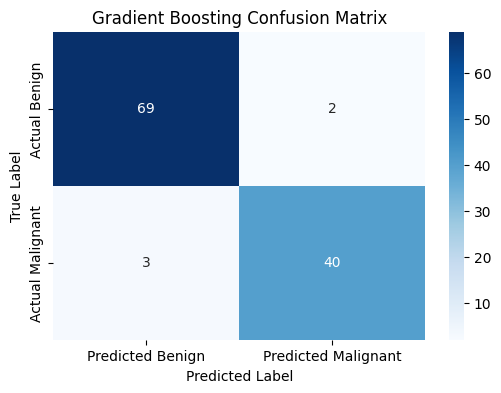

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])

plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()